In [ ]:
import sys, os, importlib
sys.path.insert(0, "/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")
os.chdir("/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")

import helpers.plot_scenario_comparison_helper as _helper
importlib.reload(_helper)
from helpers.plot_scenario_comparison_helper import collect_coopt_sweep, plot_coopt_sweep_comparison

df = collect_coopt_sweep(
    base_input_dir="data/loadprofiles",
    housing_type="single-family-detached",
    scenarios=["baseline_coopt", "full_electric_ev_coopt"],
    counties=["alameda"],
)

fig = plot_coopt_sweep_comparison(df, county="alameda")
fig.savefig("analysis_results/coopt_sweep_comparison_alameda.png", dpi=150)
fig.show()

In [ ]:
import sys, os, importlib
sys.path.insert(0, "/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")
os.chdir("/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")

import helpers.plot_scenario_comparison_helper as _helper
importlib.reload(_helper)
from helpers.plot_scenario_comparison_helper import collect_coopt_sweep, plot_coopt_sweep_comparison
county = "fresno"

df = collect_coopt_sweep(
    base_input_dir="data/loadprofiles",
    housing_type="single-family-detached",
    scenarios=["baseline_coopt", "full_electric_ev_coopt"],
    counties=[county],
)

fig = plot_coopt_sweep_comparison(df, county=county)
fig.savefig(f"analysis_results/coopt_sweep_comparison_{county}.png", dpi=150)
fig.show()

/var/folders/gr/g6k4s8t13n98c8bw4ywdpxrr0000gn/T/ipykernel_50207/950221025.py:35: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  sq      = float(df.loc[df["scenario"]=="baseline_ice_car",      "total_eac"])
/var/folders/gr/g6k4s8t13n98c8bw4ywdpxrr0000gn/T/ipykernel_50207/950221025.py:36: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  fe      = float(df.loc[df["scenario"]=="full_electric_ev",       "total_eac"])
/var/folders/gr/g6k4s8t13n98c8bw4ywdpxrr0000gn/T/ipykernel_50207/950221025.py:37: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  fecoopt = float(df.loc[df["scenario"]=="full_electric_ev_coopt", "total_eac"])
/var/folders/gr/g6k4s8t13n98c8bw4ywdpxrr0000gn/T/ipykernel_50207/950221025.py:47: U

Gas status quo (with solar):          $15,135/yr
Full electric + EV (fixed PV):        $13,686/yr  (Δ -1,449/yr vs status quo)
Full electric + EV (co-opt solar):    $12,619/yr  (Δ -2,516/yr vs status quo)

→ Claim 3: co-opt beats gas status quo by $2,516/yr (16.6%)
→ Claim 4: co-optimization adds        $1,067/yr savings over fixed PV sizing


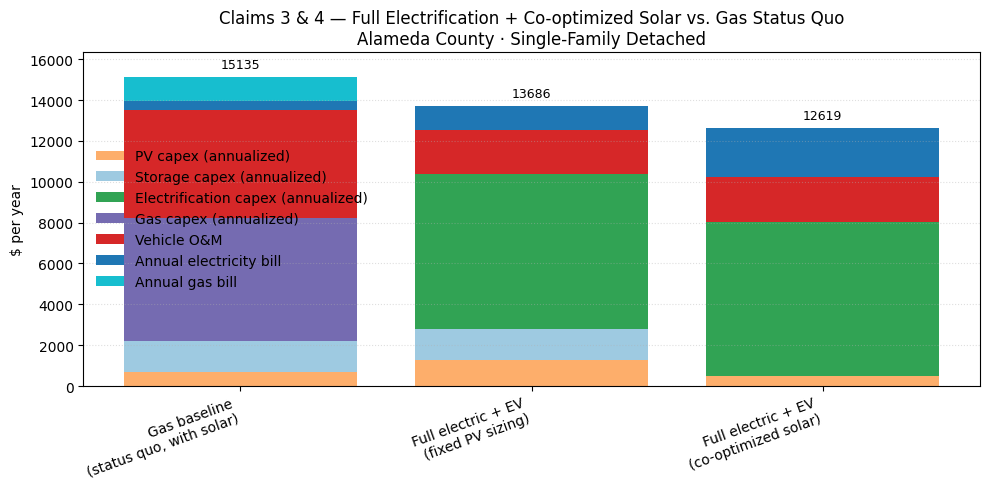

In [12]:

import sys, os
sys.path.insert(0, "/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")
os.chdir("/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage")

import pandas as pd
from helpers.plot_scenario_comparison_helper import plot_eac_stacked_bar

# ── Load the most recent step18 EAC data (all scenarios, Alameda) ────────────
df = pd.read_csv("analysis_results/step18_eac_by_county_nem3_g009aee4.csv")
df["total_eac"] = df[["capex_pv","capex_storage","capex_electric","capex_gas",
                       "annual_bill_electric","annual_bill_gas","vehicle_om"]].sum(axis=1)

# ── Claim 3+4: three-scenario comparison ─────────────────────────────────────
# Claim 3: does co-optimized full electrification beat staying gas?
# Claim 4: how much does co-optimization add on top of fixed PV sizing?

selected = ["baseline_ice_car", "full_electric_ev", "full_electric_ev_coopt"]
labels = {
    "baseline_ice_car":      "Gas baseline\n(status quo, with solar)",
    "full_electric_ev":      "Full electric + EV\n(fixed PV sizing)",
    "full_electric_ev_coopt":"Full electric + EV\n(co-optimized solar)",
}

plot_df = df[df["scenario"].isin(selected)].copy()
plot_df["scenario"] = plot_df["scenario"].map(labels)
scenario_order = [labels[s] for s in selected]

fig = plot_eac_stacked_bar(
    plot_df,
    scenario_order=scenario_order,
    title="Claims 3 & 4 — Full Electrification + Co-optimized Solar vs. Gas Status Quo\nAlameda County · Single-Family Detached",
)

# ── Print the headline numbers ────────────────────────────────────────────────
sq      = float(df.loc[df["scenario"]=="baseline_ice_car",      "total_eac"])
fe      = float(df.loc[df["scenario"]=="full_electric_ev",       "total_eac"])
fecoopt = float(df.loc[df["scenario"]=="full_electric_ev_coopt", "total_eac"])

print(f"Gas status quo (with solar):          ${sq:,.0f}/yr")
print(f"Full electric + EV (fixed PV):        ${fe:,.0f}/yr  (Δ {fe-sq:+,.0f}/yr vs status quo)")
print(f"Full electric + EV (co-opt solar):    ${fecoopt:,.0f}/yr  (Δ {fecoopt-sq:+,.0f}/yr vs status quo)")
print()
print(f"→ Claim 3: co-opt beats gas status quo by ${sq-fecoopt:,.0f}/yr ({(sq-fecoopt)/sq:.1%})")
print(f"→ Claim 4: co-optimization adds        ${fe-fecoopt:,.0f}/yr savings over fixed PV sizing")

fig.savefig("analysis_results/claims3_4_eac_comparison_alameda.png", dpi=150, bbox_inches="tight")
fig.show()
